# training.ipynb

This notebook performs the actual YOLOv8 training using the Ultralytics library. It uses a pretrained `yolov8n.pt` checkpoint, overrides the number of classes to 7 (`nc=7`) to match the dataset, and trains for 100 epochs on the preprocessed YOLO dataset (generated by `preprocessing.ipynb`). Training is performed on CPU with an image size of 256, batch size of 16, and default augmentation settings. The notebook logs per-epoch losses (box, cls, dfl) and validation metrics (Precision, Recall, mAP50, mAP50-95).

In [16]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # small pretrained model
results = model.train(
    data="yolo_dataset/data.yaml",
    epochs=100,
    imgsz=256,
    batch=16,
    device="cpu"
)

Ultralytics 8.4.51 🚀 Python-3.14.5 torch-2.12.0+cu130 CPU (AMD Ryzen 9 9900X 12-Core Processor)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patienc

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



     92/100         0G      1.752      1.274       0.98        389        256: 100% ━━━━━━━━━━━━ 797/797 4.4it/s 3:03<0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 100/100 3.2it/s 30.8s.3ss
                   all       3187      99804        0.2     0.0502     0.0269     0.0108

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     93/100         0G      1.755      1.265     0.9799        194        256: 100% ━━━━━━━━━━━━ 797/797 4.4it/s 3:03<0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 100/100 3.3it/s 30.7s.3ss
                   all       3187      99804        0.2     0.0502      0.027     0.0108

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     94/100         0G      1.741      1.262     0.9805        118        256: 100% ━━━━━━━━━━━━ 797/797 4.4it/s 3:03<0.2s
                 Class     

In [1]:
from ultralytics import YOLO

In [2]:
model = YOLO("runs/detect/train/weights/best.pt")

In [3]:
results = model("yolo_dataset/images/train//marius_hills_r00011_c00040.png")


image 1/1 ../../Moon-Recognition/notebooks/yolo_dataset/images/train/marius_hills_r00011_c00040.png: 256x256 49 class0s, 17.4ms
Speed: 0.3ms preprocess, 17.4ms inference, 0.4ms postprocess per image at shape (1, 3, 256, 256)


In [7]:
results = model.predict(source="yolo_dataset/images/train/marius_hills_r00021_c00030.png",
    conf=0.5,          # only higher-confidence detections
    imgsz=512,
    device="cpu"
)


image 1/1 ../../Moon-Recognition/notebooks/yolo_dataset/images/train/marius_hills_r00021_c00030.png: 512x512 3 class0s, 15.6ms
Speed: 0.8ms preprocess, 15.6ms inference, 0.4ms postprocess per image at shape (1, 3, 512, 512)


In [8]:
import matplotlib.pyplot as plt

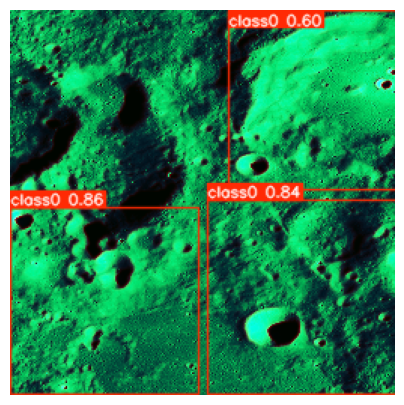

In [9]:
res = results[0]
img_with_boxes = res.plot(line_width=1)    # default draws labels; see next step
plt.figure(figsize=(5, 5))
plt.imshow(img_with_boxes)
plt.axis("off")
plt.show()